/var/folders/0z/jzy84wyd31l6p7_kz4wk0mkc0000gn/T/ipykernel_61592/1846566681.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="std", y=stats.index, data=stats.reset_index(), palette="viridis")


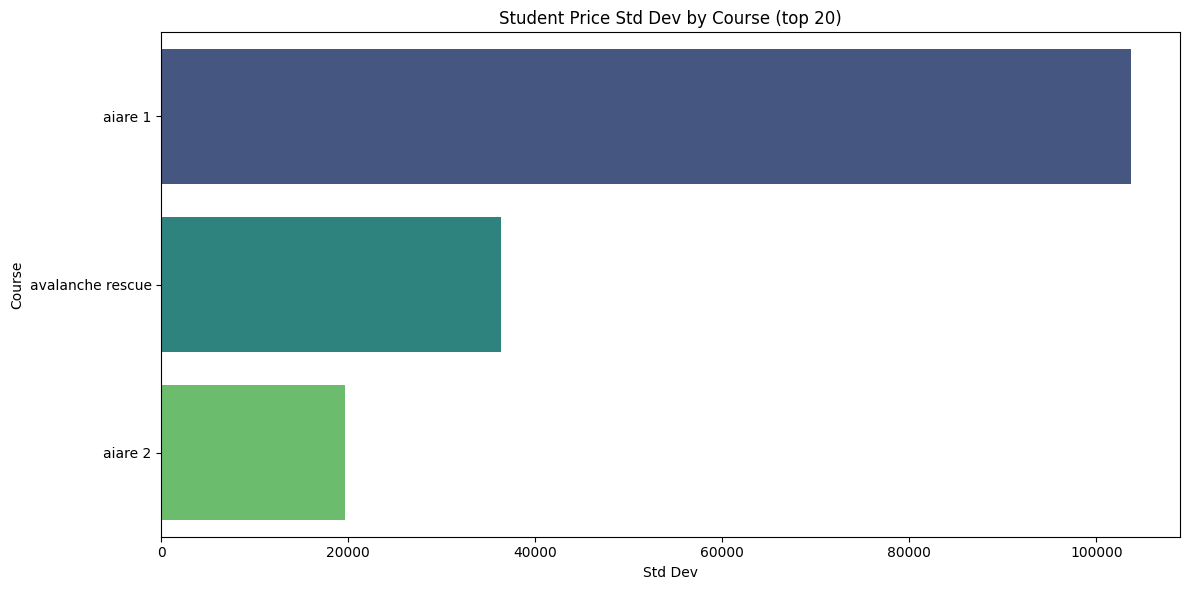

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv(r"/Users/maxinenussbaum/Desktop/git/aiare_forecasting/data/cleaned_data/course_enrollment.csv")
stats = df.groupby("combined_course")["student_price"].agg(["mean", "std", "count"]).sort_values("std", ascending=False).head(20)

plt.figure(figsize=(12,6))
sns.barplot(x="std", y=stats.index, data=stats.reset_index(), palette="viridis")
plt.title("Student Price Std Dev by Course (top 20)")
plt.xlabel("Std Dev")
plt.ylabel("Course")
plt.tight_layout()
plt.show()

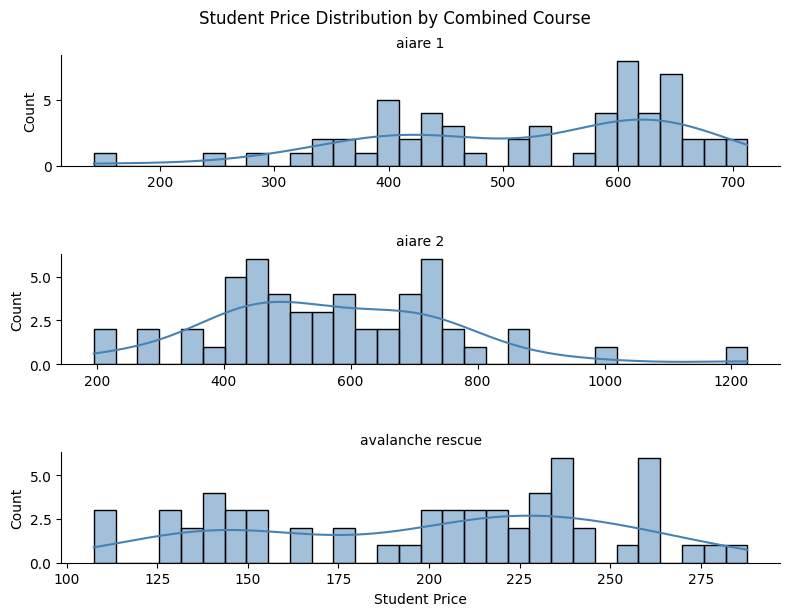

In [51]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load cleaned course enrollment data
df = pd.read_csv(r"/Users/maxinenussbaum/Desktop/git/aiare_forecasting/data/cleaned_data/course_enrollment.csv")
df = df[(df['student_price']<2000) & (df['student_price']>100)]

df["student_price"] = pd.to_numeric(df["student_price"], errors="coerce")
df = df.dropna(subset=["student_price", "combined_course"])  # ensure valid values

# Limit to top 12 combined_course categories by sample size
top_courses = (
    df.groupby("combined_course")["student_price"]
      .count()
      .sort_values(ascending=False)
      .head(12)
      .index
)
plot_df = df[df["combined_course"].isin(top_courses)]

# Faceted distribution histograms (and KDE) per combined_course
g = sns.FacetGrid(plot_df, row="combined_course", aspect=4, height=2.0, sharex=False, sharey=False)
g.map(sns.histplot, "student_price", bins=30, kde=True, color="steelblue")
g.set_axis_labels("Student Price", "Count")
g.set_titles("{row_name}")
plt.subplots_adjust(hspace=0.8)
plt.suptitle("Student Price Distribution by Combined Course", y=1.02)
plt.show()

In [50]:
df = pd.read_csv(r"/Users/maxinenussbaum/Desktop/git/aiare_forecasting/data/cleaned_data/course_location_price.csv")

# Derive country from Location if not already present: use last comma element
if "Location" in df.columns:
    df["country"] = (
        df["Location"].astype(str)
          .str.split(",")
          .apply(lambda parts: parts[-1].strip() if len(parts) > 0 else "")
    )
else:
    df["country"] = ""

# Display with derived country
result = df[df["country"] == "United States"]  # filter to rows with valid country
result.sort_values("Student Price", ascending=False, inplace=True)
result.groupby(["Student Price", "combined_course"]).agg({"Student Price": "count"}).head(50)

# result = result[(result['Student Price']<1500) & (result['Student Price']>0)]



Student Price
Student Price combined_course                
0.00          aiare 1                     380
              aiare 2                      62
              avalanche rescue            194
0.01          aiare 1                       1
              aiare 2                       1
              avalanche rescue              2
1.00          aiare 1                      36
              aiare 2                       6
              avalanche rescue             22
1.50          aiare 1                       1
6.00          aiare 1                       1
              avalanche rescue              1
10.00         aiare 1                       5
              avalanche rescue              6
12.00         aiare 1                       1
              avalanche rescue              1
15.00         avalanche rescue              4
20.00         aiare 1                       4
              aiare 2                       1
              avalanche rescue              9
25.00         avalanche rescue             12
30.00         aiare 1                       2
              aiare 2                       1
              avalanche rescue              5
35.00         aiare 1                       6
              aiare 2                       3
              avalanche rescue              1
40.00         avalanche rescue              2
45.00         avalanche rescue              1
50.00         aiare 1                       4
              avalanche rescue              8
53.00         aiare 1                       4
55.00         aiare 2                       3
57.39         avalanche rescue              1
60.00         avalanche rescue              2
65.00         avalanche rescue             19
69.00         aiare 1                       3
70.00         aiare 1                      20
              aiare 2                       4
72.00         aiare 1                       3
73.00         avalanche rescue              2
75.00         aiare 1                       1
              avalanche rescue              3
80.00         avalanche rescue              5
85.00         avalanche rescue              3
90.00         aiare 1                       7
              avalanche rescue              3
90.39         avalanche rescue              1
95.00         aiare 1                      18
              aiare 2                       6

In [ ]:
# Aggregate course price with outlier removal by combined_course quantiles
course_df = pd.read_csv(r"/Users/maxinenussbaum/Desktop/git/aiare_forecasting/data/cleaned_data/course_enrollment.csv")
course_df["student_price"] = pd.to_numeric(course_df["student_price"], errors="coerce")
course_df = course_df.dropna(subset=["student_price", "month", "year", "combined_course"])  # ensure required

# Compute 10th/90th percentile bounds within each combined_course group
quantile_bounds = (
    course_df.groupby("combined_course")["student_price"]
    .quantile([0.10, 0.90])
    .unstack(level=-1)
    .rename(columns={0.10: "q10", 0.90: "q90"})
)

# Join bounds back to course_df
course_df = course_df.merge(
    quantile_bounds[["q10", "q90"]],
    left_on="combined_course",
    right_index=True,
    how="left"
)

# Filter outliers using group-specific 10/90 bounds
cleaned = course_df[
    (course_df["student_price"] >= course_df["q10"]) &
    (course_df["student_price"] <= course_df["q90"])
].copy()

final = (
    cleaned.groupby(['year', 'month', 'combined_course'], as_index=False)
    ['student_price']
    .mean()
    .rename(columns={'student_price': 'mean_student_price'})
    .sort_values(['year', 'month', 'combined_course'])
)

final.head(30)

,year,month,combined_course,mean_student_price
0,2017,7,aiare 1,391.666667
1,2017,7,aiare 2,197.500000
2,2017,7,avalanche rescue,107.500000
3,2017,8,aiare 1,370.833333
4,2017,8,aiare 2,533.333333
5,2017,8,avalanche rescue,140.000000
6,2017,9,aiare 2,195.500000
7,2017,9,avalanche rescue,145.000000
8,2017,11,aiare 1,389.750000
9,2017,11,avalanche rescue,84.166667


In [63]:
# Utility: merge multiple dataframes on key columns
from functools import reduce

def merge_dataframes_on_keys(dfs, keys, how='outer'):
    """Merge a list of dataframes on a set of keys.

    Args:
        dfs (list[pd.DataFrame]): DataFrames to merge.
        keys (list[str]): Keys to merge on.
        how (str): Merge style (inner, outer, left, right).

    Returns:
        pd.DataFrame: Merged result.
    """
    if not isinstance(dfs, list) or len(dfs) == 0:
        raise ValueError("dfs must be a non-empty list of DataFrames")
    if not isinstance(keys, list) or len(keys) == 0:
        raise ValueError("keys must be a non-empty list of column names")

    merged_df = reduce(lambda left, right: pd.merge(left, right, on=keys, how=how), dfs)
    return merged_df

# Example usage:
# dfs = [df1, df2, df3]
df1 = pd.read_csv(r"/Users/maxinenussbaum/Desktop/git/aiare_forecasting/data/cleaned_data/course_enrollment.csv")
df2 = pd.read_csv(r"/Users/maxinenussbaum/Desktop/git/aiare_forecasting/data/cleaned_data/course_price_us.csv")
df3 = pd.read_csv(r"/Users/maxinenussbaum/Desktop/git/aiare_forecasting/data/cleaned_data/student_enrollment.csv")
keys = ['month', 'year', 'combined_course']

dfs = [df1, df2, df3]
merged = merge_dataframes_on_keys(dfs, ['year', 'month', 'combined_course'])
merged

,month,year,combined_course,enrolled,student_price,course_x,mean_student_price,id_count,course_y
0,7,2017,aiare 1,30,391.666667,AIARE 1,NaN,NaN,NaN
1,7,2017,aiare 2,12,197.500000,AIARE 2,NaN,NaN,NaN
2,7,2017,avalanche rescue,29,107.500000,Avalanche Rescue,NaN,NaN,NaN
3,8,2017,aiare 1,63,370.833333,AIARE 1,NaN,NaN,NaN
4,8,2017,aiare 2,15,533.333333,AIARE 2,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...
218,3,2026,avalanche rescue,125,262.256250,Avalanche Rescue,265.158228,74.0,Avalanche Rescue
219,4,2026,aiare 1,0,684.000000,AIARE 1 + Avalanche Rescue,672.790698,NaN,NaN
220,4,2026,aiare 2,0,1225.000000,AIARE 2,NaN,NaN,NaN
221,4,2026,avalanche rescue,0,272.625000,Avalanche Rescue,272.625000,NaN,NaN


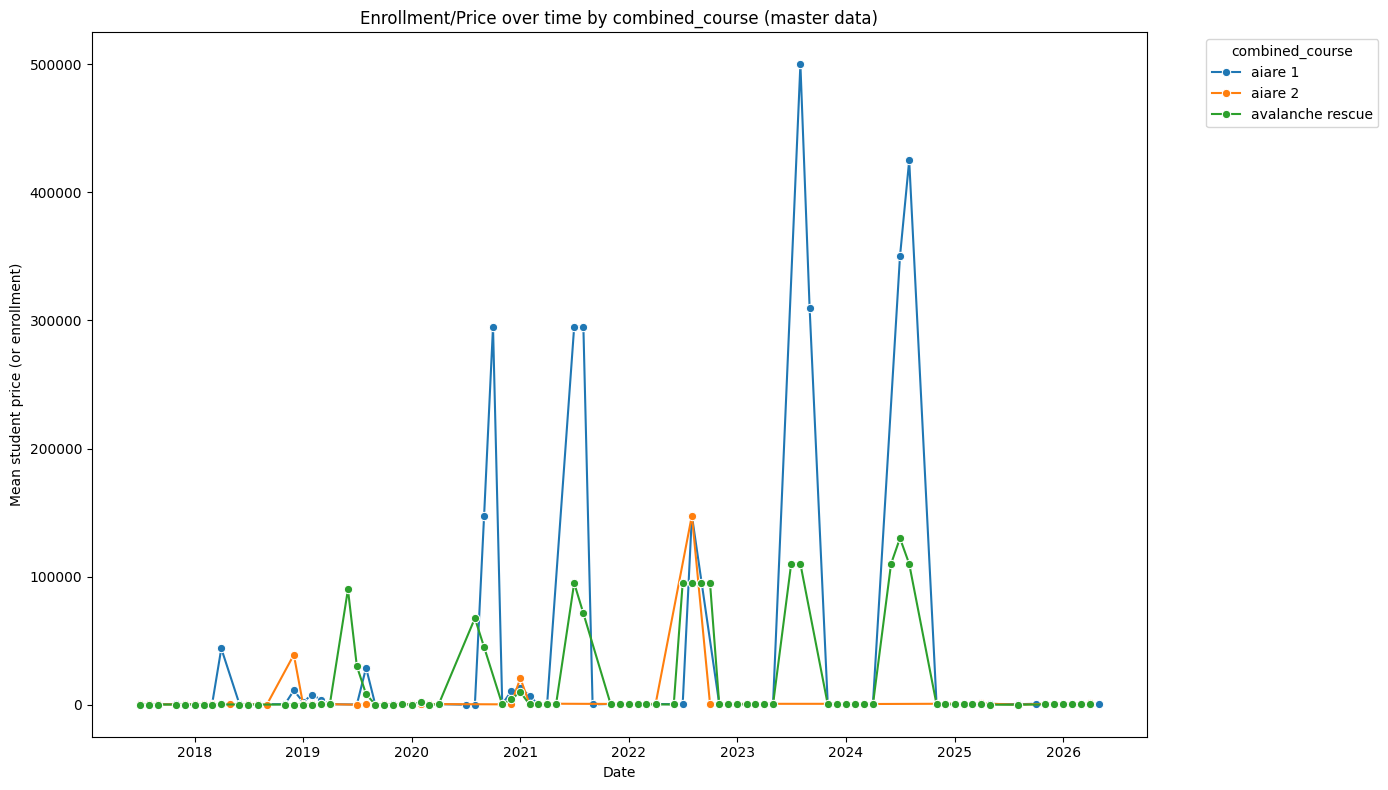

In [64]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Use master combined table (change path to your canonical master file)
master = pd.read_csv(r"/Users/maxinenussbaum/Desktop/git/aiare_forecasting/data/cleaned_data/master_data.csv")
# If your master is another file, use that path instead:
# master = pd.read_csv(r"/Users/maxinenussbaum/Desktop/git/aiare_forecasting/data/master/MASTER_COURSE_FILE.csv")

# ensure numeric and date
master["student_price"] = pd.to_numeric(master["student_price"], errors="coerce")
master["month"] = pd.to_numeric(master["month"], errors="coerce")
master["year"]  = pd.to_numeric(master["year"], errors="coerce")
master = master.dropna(subset=["student_price","month","year","combined_course"])

master["year_month"] = pd.to_datetime(master.assign(day=1)[["year","month","day"]])

top_courses = (
    master.groupby("combined_course")["student_price"].count()
    .nlargest(10).index
)
plot_df = master[master["combined_course"].isin(top_courses)]
    
plt.figure(figsize=(14,8))
sns.lineplot(
    data=plot_df,
    x="year_month",
    y="student_price",   # or use enrollment-based column from master
    hue="combined_course",
    marker="o",
)
plt.title("Enrollment/Price over time by combined_course (master data)")
plt.xlabel("Date")
plt.ylabel("Mean student price (or enrollment)")
plt.legend(title="combined_course", bbox_to_anchor=(1.05,1), loc="upper left")
plt.tight_layout()
plt.show()

AttributeError: 'Axes' object has no attribute 'plt'

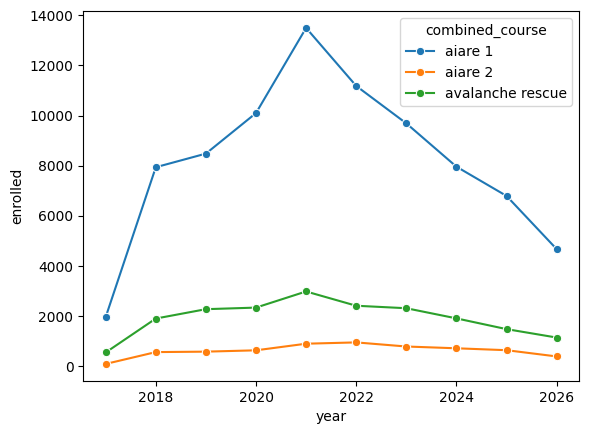

In [82]:
df = pd.read_csv(r"/Users/maxinenussbaum/Desktop/git/aiare_forecasting/data/cleaned_data/master_data.csv")
grouped = df.groupby(["year", "combined_course"], as_index=False).agg({'enrolled': 'sum', 'mean_student_price': 'mean'})
ax = sns.lineplot(
    data=grouped,
    x="year",
    y="enrolled",   # or use enrollment-based column from master
    hue="combined_course",
    marker="o",
)
ax.plt.savefig("enrollment_trends.png", dpi=300, bbox_inches='tight')

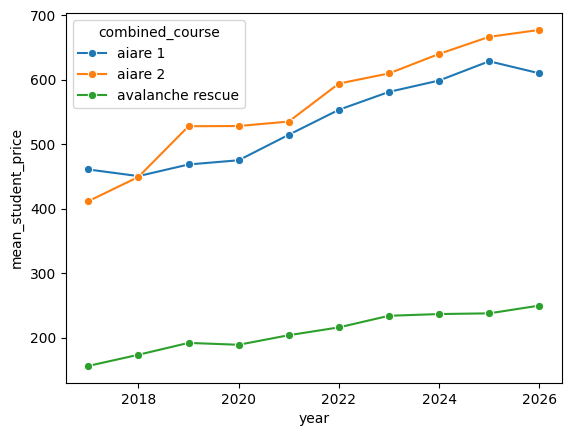

In [81]:
df = pd.read_csv(r"/Users/maxinenussbaum/Desktop/git/aiare_forecasting/data/cleaned_data/master_data.csv")
grouped = df.groupby(["year", "combined_course"], as_index=False).agg({'enrolled': 'sum', 'mean_student_price': 'mean'})
sns.lineplot(
    data=grouped,
    x="year",
    y="mean_student_price",   # or use enrollment-based column from master
    hue="combined_course",
    marker="o",
)
plt.savefig("price_trends.png", dpi=300, bbox_inches='tight')